#### ***03 — Naive Baselines***

#### ***Imports***

In [1]:
import sys
sys.path.insert(0, '..')   # make `scripts/` importable from the notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.evaluation import evaluate_model

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

#### ***Load processed data and split***

In [2]:
data = pd.read_csv('../data/processed_daily.csv', parse_dates=['date'], index_col='date')

TEST_DAYS = 30
HORIZON   = 7
SEASON    = 7

split_date = data.index.max() - pd.Timedelta(days=TEST_DAYS - 1)
train = data.loc[data.index <  split_date, 'energy_kwh']
test  = data.loc[data.index >= split_date, 'energy_kwh']

print(f'Train: {len(train)} days   ({train.index.min().date()} -> {train.index.max().date()})')
print(f'Test : {len(test)} days   ({test.index.min().date()} -> {test.index.max().date()})')
print(f'Rolling windows of {HORIZON} days within the test set: {len(test) // HORIZON}')

Train: 1897 days   (2018-08-22 -> 2023-10-31)
Test : 30 days   (2023-11-01 -> 2023-11-30)
Rolling windows of 7 days within the test set: 4


#### ***Baselines as `forecast_fn(history, horizon)` callables***

We set up the evaluator to expect a `(history, horizon) -> np.ndarray` interface from every model. Each baseline below uses *only* the history passed in — never future test data.

In [3]:
def baseline_historical_mean(history, horizon):
    return np.full(horizon, history.mean())

def baseline_last_value(history, horizon):
    return np.full(horizon, history.iloc[-1])

def baseline_seasonal_naive(history, horizon, season=SEASON):
    # Tile the most recent `season` observations across the forecast horizon
    last_season = history.iloc[-season:].values
    return np.tile(last_season, int(np.ceil(horizon / season)))[:horizon]

def baseline_drift(history, horizon):
    # Connect the first and last training points and extrapolate linearly
    T = len(history)
    slope = (history.iloc[-1] - history.iloc[0]) / (T - 1)
    return history.iloc[-1] + slope * np.arange(1, horizon + 1)

baselines = {
    'Historical mean': baseline_historical_mean,
    'Last value':      baseline_last_value,
    'Seasonal naive':  baseline_seasonal_naive,
    'Drift':           baseline_drift,
}

#### ***Run the rolling-origin evaluation***

For every baseline we get back:
- `windows`      — predictions + actuals per 7-day window;
- `per_window`   — every metric, one row per window;
- `summary`      — `mean` / `std` of each metric across the 4 windows.

In [4]:
results = {}
for name, fn in baselines.items():
    windows, per_window, summary = evaluate_model(fn, train, test, horizon=HORIZON, season=SEASON)
    results[name] = {'windows': windows, 'per_window': per_window, 'summary': summary}

# Quick sanity check
for name, r in results.items():
    print(f'{name}: {len(r["windows"])} windows, metrics = {list(r["per_window"].columns)[2:]}')

Historical mean: 4 windows, metrics = ['MAE', 'RMSE', 'MAPE', 'sMAPE', 'Bias', 'R2', 'MASE']
Last value: 4 windows, metrics = ['MAE', 'RMSE', 'MAPE', 'sMAPE', 'Bias', 'R2', 'MASE']
Seasonal naive: 4 windows, metrics = ['MAE', 'RMSE', 'MAPE', 'sMAPE', 'Bias', 'R2', 'MASE']
Drift: 4 windows, metrics = ['MAE', 'RMSE', 'MAPE', 'sMAPE', 'Bias', 'R2', 'MASE']


#### ***Per-window metrics — one row per (model, window)***

In [5]:
per_window_long = pd.concat(
    {name: r['per_window'] for name, r in results.items()},
    names=['model']
).reset_index(level=0)

# Show the per-window MAE / MASE table for a quick visual
pivot_mae = per_window_long.pivot(index='window', columns='model', values='MAE')
pivot_mae.style.format('{:.2f}').set_caption('Per-window MAE (kWh)')

model,Drift,Historical mean,Last value,Seasonal naive
window,,,,
1,20.21,27.02,20.21,29.57
2,25.57,31.76,25.51,20.19
3,49.31,31.53,49.31,50.83
4,29.88,30.21,29.87,39.34


In [6]:
pivot_mase = per_window_long.pivot(index='window', columns='model', values='MASE')
pivot_mase.style.format('{:.3f}').set_caption('Per-window MASE')

model,Drift,Historical mean,Last value,Seasonal naive
window,,,,
1,0.511,0.683,0.511,0.747
2,0.646,0.803,0.645,0.511
3,1.247,0.797,1.247,1.285
4,0.755,0.764,0.755,0.994


#### ***Aggregated leaderboard — mean ± std across the 4 windows***

In [7]:
summary_df = pd.DataFrame({name: r['summary'] for name, r in results.items()}).T

# Compact view: mean (std) per metric
def fmt(row, m):
    return f'{row[f"{m}_mean"]:.2f} ± {row[f"{m}_std"]:.2f}'

compact = pd.DataFrame({
    'MAE':   summary_df.apply(lambda r: fmt(r, 'MAE'),   axis=1),
    'RMSE':  summary_df.apply(lambda r: fmt(r, 'RMSE'),  axis=1),
    'MAPE':  summary_df.apply(lambda r: f'{r["MAPE_mean"]*100:5.1f}% ± {r["MAPE_std"]*100:4.1f}%',   axis=1),
    'sMAPE': summary_df.apply(lambda r: f'{r["sMAPE_mean"]*100:5.1f}% ± {r["sMAPE_std"]*100:4.1f}%', axis=1),
    'MASE':  summary_df.apply(lambda r: fmt(r, 'MASE'),  axis=1),
    'Bias':  summary_df.apply(lambda r: f'{r["Bias_mean"]:+.2f}',  axis=1),
    'R²':    summary_df.apply(lambda r: f'{r["R2_mean"]:+.2f}',    axis=1),
})
compact.sort_values('MASE')

,MAE,RMSE,MAPE,sMAPE,MASE,Bias,R²
Historical mean,30.13 ± 2.18,34.87 ± 2.97,89.9% ± 29.0%,52.3% ± 8.0%,0.76 ± 0.06,+14.42,-1.21
Last value,31.22 ± 12.69,37.08 ± 13.78,61.0% ± 24.9%,57.9% ± 21.1%,0.79 ± 0.32,-10.33,-1.02
Drift,31.24 ± 12.68,37.09 ± 13.77,61.1% ± 25.0%,57.9% ± 21.1%,0.79 ± 0.32,-10.29,-1.03
Seasonal naive,34.98 ± 13.14,41.57 ± 12.40,79.6% ± 25.5%,60.8% ± 20.4%,0.88 ± 0.33,-4.10,-1.68


#### ***MAE per window — visual comparison***

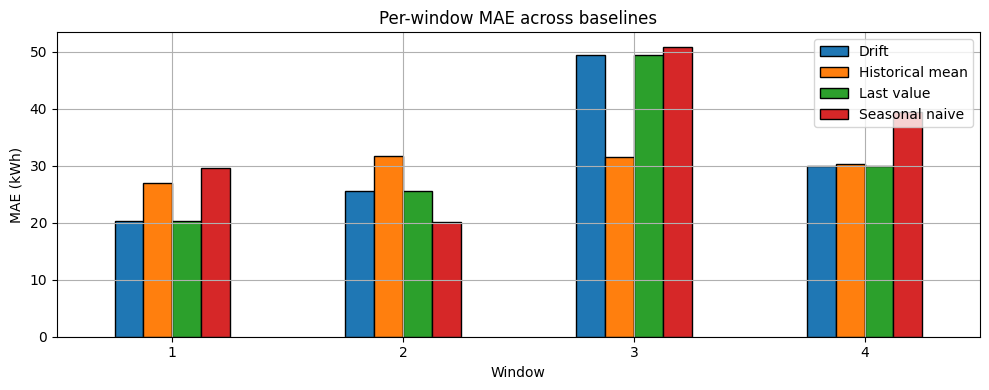

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
pivot_mae.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_xlabel('Window'); ax.set_ylabel('MAE (kWh)')
ax.set_title('Per-window MAE across baselines')
ax.legend(loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### ***Forecasts vs actuals — every window stitched in sequence***

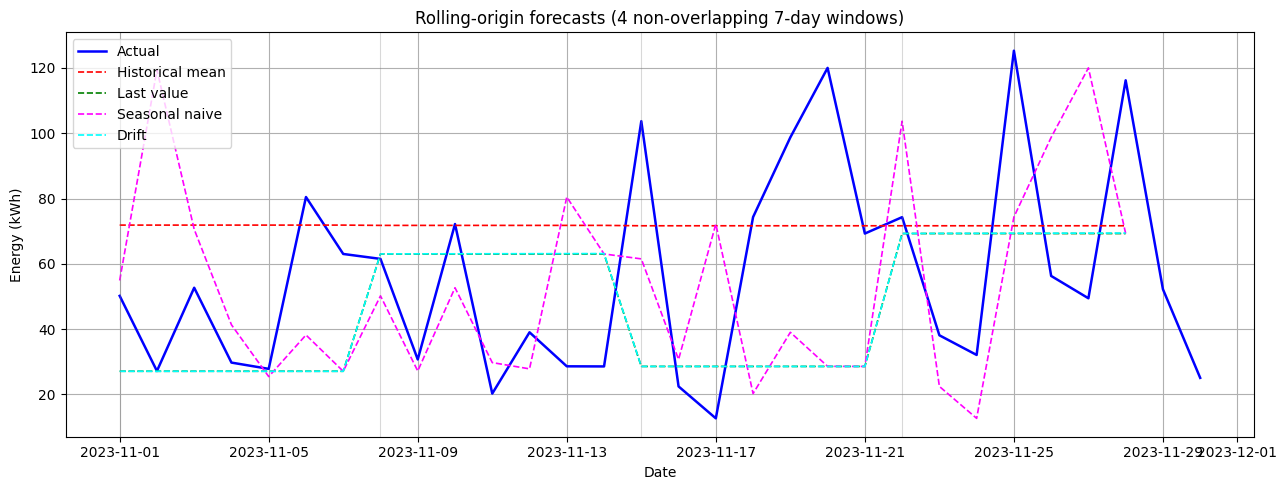

In [9]:
colors = {'Historical mean': 'red', 'Last value': 'green', 'Seasonal naive': 'magenta', 'Drift': 'cyan'}

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test.index, test.values, 'b-', lw=1.8, label='Actual')

for name, r in results.items():
    # Concatenate predictions of all 4 windows in order
    idx   = np.concatenate([w['index']       for w in r['windows']])
    preds = np.concatenate([w['predictions'] for w in r['windows']])
    ax.plot(idx, preds, '--', color=colors[name], lw=1.2, label=name)

# Mark window boundaries
for w in results['Historical mean']['windows']:
    ax.axvline(w['index'][0], color='grey', alpha=0.3, lw=0.8)

ax.set_xlabel('Date'); ax.set_ylabel('Energy (kWh)')
ax.set_title('Rolling-origin forecasts (4 non-overlapping 7-day windows)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()